# Задание 6: классификация текстов

В этом задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [50]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [51]:
url = "https://github.com/hse-ds/iad-intro-ds/blob/master/2024/homeworks/hw06_texts/tweets_coronavirus.csv?raw=true"

df = pd.read_csv(url, encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
20356,28632,73584,"Toronto, Ontario",27-03-2020,"credit card tapping, new technologies like Dys...",Extremely Positive
9179,14937,59889,"Feeding Birds, Hugging Trees",20-03-2020,@THemingford Yes #Boris just overlooked comple...,Negative
27056,36980,81932,"Vancouver, British Columbia",07-04-2020,Man charged for allegedly spitting in cop's fa...,Extremely Negative
12585,19056,64008,NaN,22-03-2020,#coronavirus Let us thank all of the healthcar...,Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная эмоциональная окраска и 0 - если отрицательная.

In [52]:
print(f"Before: {df.Sentiment.unique()}")

df.Sentiment = df.Sentiment.apply(lambda x: 1 if x in ['Positive', 'Extremely Positive'] else 0)

print(f"After: {df.Sentiment.unique()}")

Before: ['Positive' 'Extremely Negative' 'Negative' 'Extremely Positive']
After: [1 0]


Сбалансированы ли классы?

In [53]:
print(df.Sentiment.value_counts())

Sentiment
1    18046
0    15398
Name: count, dtype: int64


Отрицательных чуть меньше, но не сильно

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [54]:
print("Before:")
print(df.isnull().sum())

df.fillna('Unknown', inplace=True)

print(f"After: {df.isnull().sum().sum()}")

Before:
UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64
After: 0


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и `random_state=0`

In [55]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=42)
print(train.shape, test.shape)

(23410, 6) (10034, 6)


## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведение токенов в нижний регистр

In [56]:
texts = train.OriginalTweet

from collections import Counter

all_tokens = []
for text in texts:
  tokens = text.lower().split()
  all_tokens.extend(tokens)

token_counts = Counter(all_tokens)

Какой размер словаря получился?

In [57]:
print(len(token_counts))

79513


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе

In [58]:
top_10 = token_counts.most_common(10)
for token, count in top_10:
  print(f"{token}: {count}")

the: 26772
to: 23480
and: 14566
of: 13053
a: 11537
in: 11201
for: 8541
#coronavirus: 8168
is: 7396
are: 6898


Эти токены в топе потому что это предлоги, артикли и союзы английского языка, встречающиеся практически в каждом предложении. Также это хэштэг коронавируса, основной темы датасета

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [59]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

filtered_token_counts = {token: count for token, count in token_counts.items() if token not in stop_words}

top_10 = Counter(filtered_token_counts).most_common(10)
for token, count in top_10:
  print(f"{token}: {count}")

#coronavirus: 8168
prices: 3895
food: 3845
grocery: 3425
supermarket: 3278
covid-19: 3174
store: 3171
people: 3142
#covid19: 2483
consumer: 2262


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Теперь это в основном темы, которые наиболее волновали людей в начале пандемии. Цены, продовольствие, магазины, люди

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [60]:
bottom_20 = Counter(filtered_token_counts).most_common()[:-21:-1]
for token, count in bottom_20:
  print(f"{token}: {count}")

https://t.co/i2wsgmzxtg: 1
https://t.co/ksnz52unrv: 1
enraging!!: 1
https://t.co/1ioo4mlmzc: 1
islands,: 1
https://t.co/1whyfial70: 1
link,: 1
debt": 1
"surviving: 1
.@nclc4consumers: 1
https://t.co/cywvxl4hzx: 1
https://t.co/x3nflaebnk: 1
"unavoidable": 1
outflows: 1
aq:: 1
@mauriciocard: 1
colombia's: 1
https://t.co/f62lteprso: 1
https://t.co/vsiiwruts7: 1
https://t.co/jbykncmrxf: 1


В основном это мусорная информация вроде ссылок на телеграм или опечаток. В идеале их тоже нужно удалить, такие токены будут мешать модели



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [61]:
from nltk.tokenize import TweetTokenizer

texts = train.OriginalTweet
tokenizer = TweetTokenizer()

all_tokens = []
for text in texts:
  tokens = tokenizer.tokenize(text.lower())
  all_tokens.extend(tokens)

token_counts = Counter(all_tokens)

top_10 = token_counts.most_common(10)
for token, count in top_10:
  print(f"{token}: {count}")

the: 26956
.: 23945
to: 23587
,: 17430
and: 14709
of: 13082
a: 11680
in: 11342
?: 9725
#coronavirus: 8727


Отличия состоят в появлении пунктуации

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [62]:
from string import punctuation

stop_words.update(punctuation)
filtered_token_counts = {token: count for token, count in token_counts.items() if token not in stop_words}

top_10 = Counter(filtered_token_counts).most_common(10)
for token, count in top_10:
  print(f"{token}: {count}")

#coronavirus: 8727
â: 7272
: 7165
19: 7146
covid: 6211
prices: 4603
food: 4411
: 4301
store: 3862
supermarket: 3819


Что за символ А с домиком не понятно. 19 очевидно отсылает к COVID-19. Некоторые символы вообще не отображаются

Удалите из словаря токены из одного символа, с позицией в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [63]:
filtered_token_counts = {
    token: count for token, count in token_counts.items()
    if token not in stop_words
    and len(token) > 1
    and all(ord(char) < 128 for char in token)
}

top_10 = Counter(filtered_token_counts).most_common(10)
for token, count in top_10:
  print(f"{token}: {count}")

#coronavirus: 8727
19: 7146
covid: 6211
prices: 4603
food: 4411
store: 3862
supermarket: 3819
grocery: 3481
people: 3418
#covid19: 2593


In [64]:
bottom_20 = Counter(filtered_token_counts).most_common()[:-21:-1]
for token, count in bottom_20:
    print(f"{token}: {count}")

https://t.co/i2wsgmzxtg: 1
https://t.co/ksnz52unrv: 1
https://t.co/1ioo4mlmzc: 1
https://t.co/1whyfial70: 1
https://t.co/cywvxl4hzx: 1
https://t.co/x3nflaebnk: 1
outflows: 1
aq: 1
@mauriciocard: 1
colombia's: 1
https://t.co/f62lteprso: 1
https://t.co/vsiiwruts7: 1
https://t.co/jbykncmrxf: 1
karwick: 1
al's: 1
#al's: 1
hickey: 1
https://t.co/dhj10u2kso: 1
#stopprofiteering: 1
opportunism: 1


Конечно стало лучше, без бессмысленной а с домиком или артиклей. Но вот от ссылок на телеграм или хэштэга с ковидом все равно было бы славно избавиться

Выведите топ-10 популярных хештегов с количеством встреч. Что можно сказать о них?

In [65]:
import re

hashtag_pattern = r'#\w+'

all_hashtags = []
for text in texts:
    hashtags = re.findall(hashtag_pattern, text.lower())
    all_hashtags.extend(hashtags)

hashtag_counts = Counter(all_hashtags)

top_10_hashtags = hashtag_counts.most_common(10)
for hashtag, count in top_10_hashtags:
    print(f"{hashtag}: {count}")

#coronavirus: 8748
#covid19: 2596
#covid_19: 1725
#covid2019: 947
#covid: 865
#toiletpaper: 754
#socialdistancing: 468
#coronacrisis: 446
#pandemic: 245
#coronaviruspandemic: 244


Все что со словом ковид - неинформативно. У нас весь датасет с темой ковид. Туалетная бумага и социальная дистанция несут хоть какую то информацию

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [66]:
url_pattern = r'https://t\.co/\w+'
all_urls = []
for text in texts:
  urls = re.findall(url_pattern, text)
  all_urls.extend(urls)

url_counts = Counter(all_urls)

top_10_urls = url_counts.most_common(10)
for url, count in top_10_urls:
    print(f"{url}: {count}")

https://t.co/3kFUIOJXEp: 4
https://t.co/R7sAGojsjg: 4
https://t.co/WrLHYzIzAA: 4
https://t.co/OI39zSAnQ8: 3
https://t.co/gP3EusapL8: 3
https://t.co/kuwIpF1KQW: 3
https://t.co/zA8rEwpvvB: 3
https://t.co/6yVYKIAb2c: 3
https://t.co/xPcm2Xkj4O: 3
https://t.co/PE99MHrsAT: 3


Ссылки практически не используются. Максимум 3-4 раза. Такая редкая информация не сможет как-то повлиять на модель

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для изначального выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа, с позицией в таблице Unicode 128 и более и ссылки на t.co



In [67]:
def custom_tokenizer(text):

  text = text.lower()

  tokenizer = TweetTokenizer()

  tokens = tokenizer.tokenize(text)

  filtered_tokens = []
  for token in tokens:
    if re.match(r'https://t\.co/\w+', token):
      continue

    if token in stop_words:
      continue

    if len(token) <= 1:
      continue

    if any(ord(char) >= 128 for char in token):
      continue

    filtered_tokens.append(token)

  return filtered_tokens

In [68]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [69]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer, lowercase=False)

texts = train.OriginalTweet

cv.fit(texts)

print(len(cv.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


44004


Размер словаря почти вдвое меньше изначального. Модели будет явно проще обучать

Посмотрим на какой-нибудь конкретный твитт:

In [70]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Reading a ?@TorontoStar? article about grocery shopping&amp;prices during covid-19, and a line stands out: Ã\x82Â\x93Last week, PusateriÃ\x82Â\x92s ... selling $30 container of disinfectant wipes went viralÃ\x82Â\x94 &amp; IÃ\x82Â\x92m shocked. That was just last week? Feels like last month! https://t.co/lWyDuug6LX',
 np.int64(1))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [71]:
tweet_text = train.iloc[ind]['OriginalTweet']
vectorized_array = cv.transform([tweet_text]).toarray().flatten()

vocab = cv.vocabulary_
reverse_vocab = {index: token for token, index in vocab.items()}

non_zero_indices = vectorized_array.nonzero()[0]
non_zero_values = vectorized_array[non_zero_indices]

max_index = non_zero_indices[non_zero_values.argmax()]
min_index = non_zero_indices[non_zero_values.argmin()]

most_important_token = reverse_vocab[max_index]
least_important_token = reverse_vocab[min_index]

most_important_value = vectorized_array[max_index]
least_important_value = vectorized_array[min_index]

print(f"Самый важный токен: '{most_important_token}' (значение: {most_important_value})")
print(f"Самый неважный токен: '{least_important_token}' (значение: {least_important_value})")

Самый важный токен: 'last' (значение: 3)
Самый неважный токен: '...' (значение: 1)


Last отсылает нас в недалекое прошлое, видимо человек сравнивает, как изменилась ситуация во Франции за небольшой промежуток времени. Троеточие действительно в данной ситуации не очень важно

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(tokenizer=custom_tokenizer, lowercase=False)
tfidf.fit(texts)

tweet_text = train.iloc[ind]['OriginalTweet']
vectorized_array = tfidf.transform([tweet_text]).toarray().flatten()

vocab = tfidf.vocabulary_
reverse_vocab = {index: token for token, index in vocab.items()}

non_zero_indices = vectorized_array.nonzero()[0]
non_zero_values = vectorized_array[non_zero_indices]

max_index = non_zero_indices[non_zero_values.argmax()]
min_index = non_zero_indices[non_zero_values.argmin()]

most_important_token = reverse_vocab[max_index]
least_important_token = reverse_vocab[min_index]

most_important_value = vectorized_array[max_index]
least_important_value = vectorized_array[min_index]

print(f"Самый важный токен: '{most_important_token}' (значение: {most_important_value})")
print(f"Самый неважный токен: '{least_important_token}' (значение: {least_important_value})")

Самый важный токен: 'last' (значение: 0.4509466028471935)
Самый неважный токен: '19' (значение: 0.06743058165243791)


В прицнипе ничего не изменилось. Недалекое прошлое важно, а 19 очевидно отсылает нас к названию вируса, что в данном случае не несет никакой информации

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [73]:
positive_tweets = train[train['OriginalTweet'].apply(lambda x: 'great' in x) & (train['Sentiment'] == 1)]

example_tweet = positive_tweets.iloc[28]['OriginalTweet']
print(example_tweet)

vectorized_array = tfidf.transform([example_tweet]).toarray().flatten()

vocab = tfidf.vocabulary_
reverse_vocab = {index: token for token, index in vocab.items()}

non_zero_indices = vectorized_array.nonzero()[0]
non_zero_values = vectorized_array[non_zero_indices]

max_index = non_zero_indices[non_zero_values.argmax()]
min_index = non_zero_indices[non_zero_values.argmin()]

most_important_token = reverse_vocab[max_index]
least_important_token = reverse_vocab[min_index]

most_important_value = vectorized_array[max_index]
least_important_value = vectorized_array[min_index]

print(f"\nСамый важный токен: '{most_important_token}' (значение: {most_important_value:.4f})")
print(f"Самый неважный токен: '{least_important_token}' (значение: {least_important_value:.4f})")

Have a great weekend. Stay safe and happy.Things will get better soon. #coronavirus #toiletpaper #SocialDistancing #TogetherAtHome #SaturdayMorning https://t.co/kb37v4FnT5

Самый важный токен: 'happy.things' (значение: 0.4647)
Самый неважный токен: '#coronavirus' (значение: 0.0893)


Очевидно, happy относится к положительным твитам

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [74]:
X_train = train['OriginalTweet']
X_test = test['OriginalTweet']
y_train = train['Sentiment']
y_test = test['Sentiment']

count_vectorizer = CountVectorizer(tokenizer=custom_tokenizer, lowercase=False)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer, lowercase=False)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_count = LogisticRegression(max_iter=1000, random_state=42)
lr_count.fit(X_train_count, y_train)

y_train_pred_count = lr_count.predict(X_train_count)
y_test_pred_count = lr_count.predict(X_test_count)

accuracy_train_count = accuracy_score(y_train, y_train_pred_count)
accuracy_test_count = accuracy_score(y_test, y_test_pred_count)

print(f"CountVectorizer - Accuracy на обучающих данных: {accuracy_train_count:.4f}")
print(f"CountVectorizer - Accuracy на тестовых данных: {accuracy_test_count:.4f}")

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)

y_train_pred_tfidf = lr_tfidf.predict(X_train_tfidf)
y_test_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

accuracy_train_tfidf = accuracy_score(y_train, y_train_pred_tfidf)
accuracy_test_tfidf = accuracy_score(y_test, y_test_pred_tfidf)

print(f"TfidfVectorizer - Accuracy на обучающих данных: {accuracy_train_tfidf:.4f}")
print(f"TfidfVectorizer - Accuracy на тестовых данных: {accuracy_test_tfidf:.4f}")

CountVectorizer - Accuracy на обучающих данных: 0.9832
CountVectorizer - Accuracy на тестовых данных: 0.8736
TfidfVectorizer - Accuracy на обучающих данных: 0.9240
TfidfVectorizer - Accuracy на тестовых данных: 0.8503


CountVectorizer обучался дольше, но как ни странно показал результаты лучше. Видимо модель получается более сложной, но лучше обобщаемой

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [76]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer('english')

def custom_stem_tokenizer(text):

  text = text.lower()

  tokenizer = TweetTokenizer()

  tokens = tokenizer.tokenize(text)

  filtered_tokens = []
  for token in tokens:
    if re.match(r'https://t\.co/\w+', token):
      continue

    if token in stop_words:
      continue

    if len(token) <= 1:
      continue

    if any(ord(char) >= 128 for char in token):
      continue

    stemmed_token = stemmer.stem(token)

    filtered_tokens.append(stemmed_token)

  return filtered_tokens

In [77]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [78]:
count_vectorizer = CountVectorizer(tokenizer=custom_stem_tokenizer, lowercase=False)

X_count = count_vectorizer.fit_transform(train['OriginalTweet'])

vocab_size_count = len(count_vectorizer.vocabulary_)
print(f'CountVectorizer vocabulary = {vocab_size_count}')

tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_stem_tokenizer, lowercase=False)

X_tfidf = tfidf_vectorizer.fit_transform(train['OriginalTweet'])

vocab_size_tfidf = len(tfidf_vectorizer.vocabulary_)
print(f'TfidfVectorizer vocabulary = {vocab_size_tfidf}')

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


CountVectorizer vocabulary = 35379
TfidfVectorizer vocabulary = 35379


Размер словаря снизился, это может помочь модели достичь более высокой точности

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [79]:
X_train = train['OriginalTweet']
X_test = test['OriginalTweet']
y_train = train['Sentiment']
y_test = test['Sentiment']

count_vectorizer = CountVectorizer(tokenizer=custom_stem_tokenizer, lowercase=False)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_stem_tokenizer, lowercase=False)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

lr_count = LogisticRegression(max_iter=1000, random_state=42)
lr_count.fit(X_train_count, y_train)

y_train_pred_count = lr_count.predict(X_train_count)
y_test_pred_count = lr_count.predict(X_test_count)

accuracy_train_count = accuracy_score(y_train, y_train_pred_count)
accuracy_test_count = accuracy_score(y_test, y_test_pred_count)

print(f"CountVectorizer - Accuracy на обучающих данных: {accuracy_train_count:.4f}")
print(f"CountVectorizer - Accuracy на тестовых данных: {accuracy_test_count:.4f}")

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)

y_train_pred_tfidf = lr_tfidf.predict(X_train_tfidf)
y_test_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

accuracy_train_tfidf = accuracy_score(y_train, y_train_pred_tfidf)
accuracy_test_tfidf = accuracy_score(y_test, y_test_pred_tfidf)

print(f"TfidfVectorizer - Accuracy на обучающих данных: {accuracy_train_tfidf:.4f}")
print(f"TfidfVectorizer - Accuracy на тестовых данных: {accuracy_test_tfidf:.4f}")

CountVectorizer - Accuracy на обучающих данных: 0.9710
CountVectorizer - Accuracy на тестовых данных: 0.8757
TfidfVectorizer - Accuracy на обучающих данных: 0.9151
TfidfVectorizer - Accuracy на тестовых данных: 0.8607


Метрики слегка выросли, особенно у tfidf. Видимо смысл в стемминге все таки есть

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Выведите топ 10 самых частых и самых редких токенов. Что можно о них сказать?

In [80]:
print(f'Общее число документов в train {len(train)}')

vocab = count_vectorizer.vocabulary_
token_frequencies = X_count.sum(axis=0).A1  # Сумма по столбцам (частоты токенов)

token_frequency_df = pd.DataFrame({
    'token': list(vocab.keys()),
    'frequency': token_frequencies[list(vocab.values())]
}).sort_values(by='frequency', ascending=False)

print("Топ-10 самых популярных токенов:")
print(token_frequency_df.head(10))

print("\nТоп-10 самых редких токенов:")
print(token_frequency_df.tail(10))

Общее число документов в train 23410
Топ-10 самых популярных токенов:
            token  frequency
32   #coronavirus       8729
65             19       7146
91          covid       6211
48          price       5271
7           store       4618
22           food       4511
122   supermarket       4177
55        groceri       3737
113         peopl       3464
461          shop       2781

Топ-10 самых редких токенов:
                 token  frequency
35365          paducah          1
35364         fiendish          1
35363  recession-induc          1
35362     619 531 3507          1
35361    @virtualstock          1
35360           #grain          1
8       #retailcannabi          1
35378               aq          1
35373      #stopprofit          1
35346      #wheelchair          1


Смысла в токенах #coronavirus, 19 и covid нет никакого. У нас все тексты об этом. Нужно ограничить max_df показателем частоты covid, то есть 0.2653. Точно так же мало смысла в очень редких токенах, они не позволяют нам сделать какой-либо вывод о данных ибо они встречаются буквально один раз

Подберите min_df и max_df в CountVectorizer таким образом, чтобы размер словаря был около 3800 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [81]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=0.25, min_df=0.0004
                        ).fit(X_train)
print(len(cv_df.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


3876


In [82]:
X_train_count = cv_df.transform(X_train)
X_test_count = cv_df.transform(X_test)

lr_count = LogisticRegression(max_iter=1000, random_state=42)
lr_count.fit(X_train_count, y_train)

y_train_pred_count = lr_count.predict(X_train_count)
y_test_pred_count = lr_count.predict(X_test_count)

accuracy_train_count = accuracy_score(y_train, y_train_pred_count)
accuracy_test_count = accuracy_score(y_test, y_test_pred_count)

print(f"CountVectorizer_df - Accuracy на обучающих данных: {accuracy_train_count:.4f}")
print(f"CountVectorizer_df - Accuracy на тестовых данных: {accuracy_test_count:.4f}")

CountVectorizer_df - Accuracy на обучающих данных: 0.9298
CountVectorizer_df - Accuracy на тестовых данных: 0.8729


Метрики практически не изменились, а размер словаря уменьшился в 10 раз. Это говорит о том, что очень много токенов были лишними, они не несли важной информации

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `berplot` содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_count)
X_test_scaled = scaler.transform(X_test_count)

lr_scaled = LogisticRegression(max_iter=1000, random_state=42)
lr_scaled.fit(X_train_scaled, y_train)

y_train_pred_scaled = lr_scaled.predict(X_train_scaled)
y_test_pred_scaled = lr_scaled.predict(X_test_scaled)

accuracy_train_scaled = accuracy_score(y_train, y_train_pred_scaled)
accuracy_test_scaled = accuracy_score(y_test, y_test_pred_scaled)

print(f"CountVectorizer_df (scaled) - Accuracy на обучающих данных: {accuracy_train_scaled:.4f}")
print(f"CountVectorizer_df (scaled) - Accuracy на тестовых данных: {accuracy_test_scaled:.4f}")

CountVectorizer_df (scaled) - Accuracy на обучающих данных: 0.9457
CountVectorizer_df (scaled) - Accuracy на тестовых данных: 0.8473


<ipython-input-84-d62757fb44e5>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_positive_tokens, x='weight', y='token', palette='Blues_d')
<ipython-input-84-d62757fb44e5>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_negative_tokens, x='weight', y='token', palette='Reds_d')


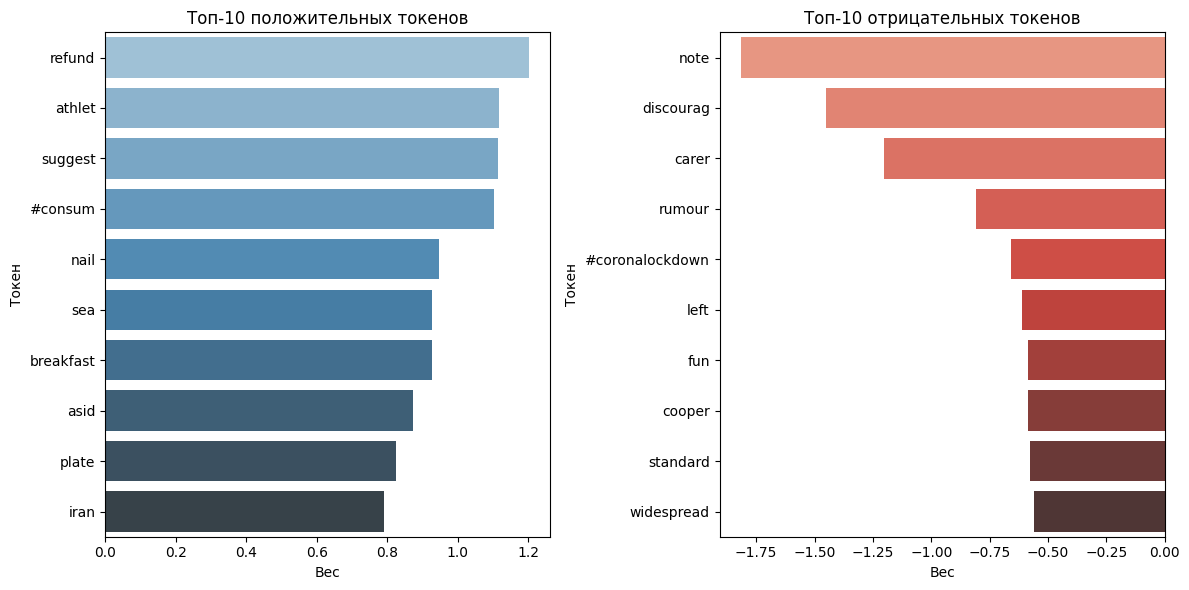

In [84]:
weights = lr_scaled.coef_[0]
tokens = list(cv_df.vocabulary_.keys())
weights_df = pd.DataFrame({'token': tokens, 'weight': weights})

top_positive_tokens = weights_df.nlargest(10, 'weight')
top_negative_tokens = weights_df.nsmallest(10, 'weight')

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=top_positive_tokens, x='weight', y='token', palette='Blues_d')
plt.title('Топ-10 положительных токенов')
plt.xlabel('Вес')
plt.ylabel('Токен')

plt.subplot(1, 2, 2)
sns.barplot(data=top_negative_tokens, x='weight', y='token', palette='Reds_d')
plt.title('Топ-10 отрицательных токенов')
plt.xlabel('Вес')
plt.ylabel('Токен')

plt.tight_layout()
plt.show()

Токены отражают радости и печали населения. Люди радуются возврату, видимо, налогов, атлетам, очистившемуся морю и хорошему завтраку. Правда, что тут делает Иран не очень понятно. Люди не рады локдауну, ухудшившимся карьерным перспективам, слухам и ...запискам?? Я помню, что в то время кто-то выкладывал записки людей на ИВЛ в Коммунарке, они всех напугали. Либо note как глагол замечать, возможно, кто-то из известных людей был замечен без маски или на вечеринке, что воспринималось резко негативно

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [85]:
print(f'Размер тренировочной выборки: {len(train)}\n')

print(f"Количество уникальных UserName: {train['UserName'].nunique()}")
print(f"Количество уникальных ScreenName: {train['ScreenName'].nunique()}")

print("\nПример UserName:")
print(train['UserName'].value_counts().head())
print("\nПример ScreenName:")
print(train['ScreenName'].value_counts().head())

Размер тренировочной выборки: 23410

Количество уникальных UserName: 23410
Количество уникальных ScreenName: 23410

Пример UserName:
UserName
22999    1
31121    1
35223    1
26861    1
26222    1
Name: count, dtype: int64

Пример ScreenName:
ScreenName
67951    1
76073    1
80175    1
71813    1
71174    1
Name: count, dtype: int64


Признаки уникальны а значит бесполезны

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на оспнове целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [86]:
print(train['TweetAt'].head())
train["TweetAt"] = pd.to_datetime(train['TweetAt'], format='%d-%m-%Y')
test["TweetAt"] = pd.to_datetime(test['TweetAt'], format='%d-%m-%Y')
print(train['TweetAt'].head())

22362    03-04-2020
4489     19-03-2020
31974    12-04-2020
31210    11-04-2020
14358    23-03-2020
Name: TweetAt, dtype: object
22362   2020-04-03
4489    2020-03-19
31974   2020-04-12
31210   2020-04-11
14358   2020-03-23
Name: TweetAt, dtype: datetime64[ns]


<Figure size 1200x600 with 0 Axes>

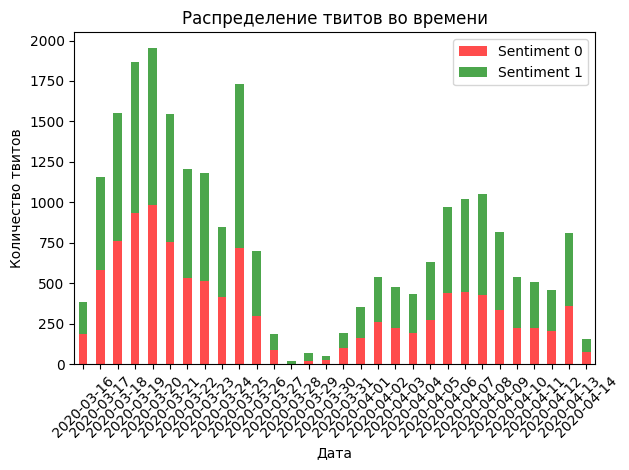

In [87]:
grouped = train.groupby([train['TweetAt'].dt.date, 'Sentiment']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))

grouped.plot(kind='bar', stacked=True, color=['red', 'green'], alpha=0.7)

plt.title('Распределение твитов во времени')
plt.xlabel('Дата')
plt.ylabel('Количество твитов')
plt.xticks(rotation=45)
plt.legend(['Sentiment 0', 'Sentiment 1'])
plt.tight_layout()
plt.show()

Как будто не видно разницы между числом положительных и отрицательных твитов. Попробуем взглянуть на разницу более подробно

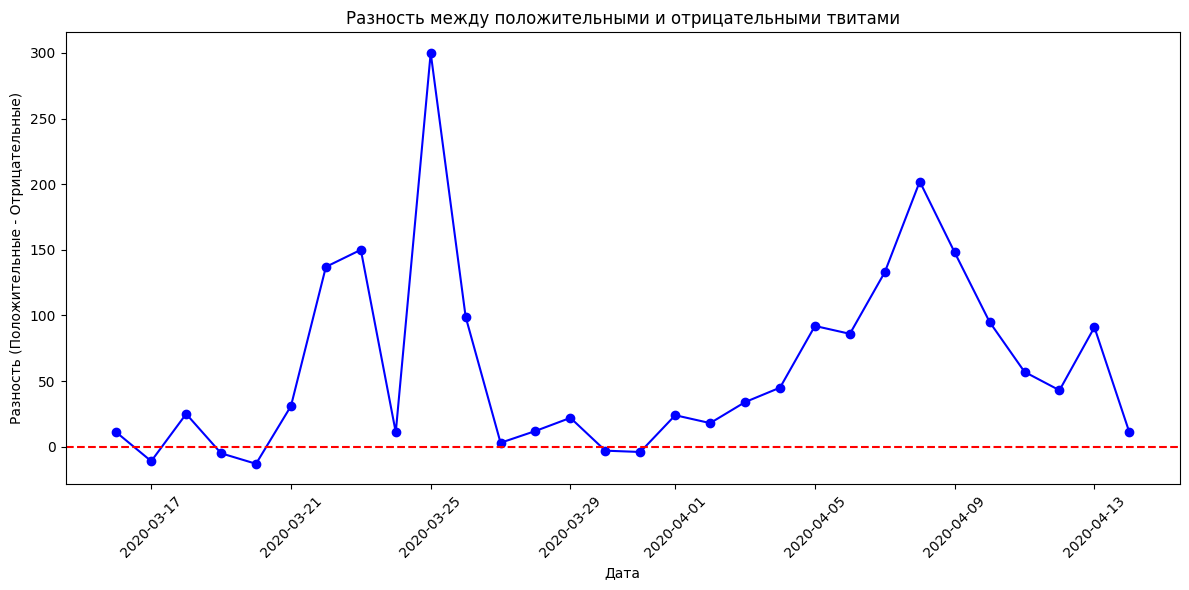

In [88]:
grouped = train.groupby([train['TweetAt'].dt.date, 'Sentiment']).size().unstack(fill_value=0)

# Вычисляем разность между положительными и отрицательными твитами
grouped['Difference'] = grouped.get(1, 0) - grouped.get(0, 0)

plt.figure(figsize=(12, 6))
plt.plot(grouped.index, grouped['Difference'], marker='o', color='blue')
plt.title('Разность между положительными и отрицательными твитами')
plt.xlabel('Дата')
plt.ylabel('Разность (Положительные - Отрицательные)')
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В целом разница крошечная, признак скорее бесполезен. Но можно попробовать обучить модель и сравнить метрики

In [89]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['TweetAt_encoded'] = le.fit_transform(train['TweetAt'])
test['TweetAt_encoded'] = le.transform(test['TweetAt'])

In [90]:
from scipy.sparse import hstack

tweet_at_encoded_train = train['TweetAt_encoded'].values.reshape(-1, 1)
tweet_at_encoded_test = test['TweetAt_encoded'].values.reshape(-1, 1)

X_train_combined = hstack([X_train_scaled, tweet_at_encoded_train])
X_test_combined = hstack([X_test_scaled, tweet_at_encoded_test])

lr_combined = LogisticRegression(max_iter=1000, random_state=42)
lr_combined.fit(X_train_combined, y_train)

y_train_pred_combined = lr_combined.predict(X_train_combined)
y_test_pred_combined = lr_combined.predict(X_test_combined)

accuracy_train_combined = accuracy_score(y_train, y_train_pred_combined)
accuracy_test_combined = accuracy_score(y_test, y_test_pred_combined)

print(f"Combined features - Accuracy на обучающих данных: {accuracy_train_combined:.4f}")
print(f"Combined features - Accuracy на тестовых данных: {accuracy_test_combined:.4f}")

Combined features - Accuracy на обучающих данных: 0.9462
Combined features - Accuracy на тестовых данных: 0.8472


Точность статистически незначимо снизилась. Признак абсолютно бесполезен


Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [91]:
print(train['Location'].nunique())

7883


Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

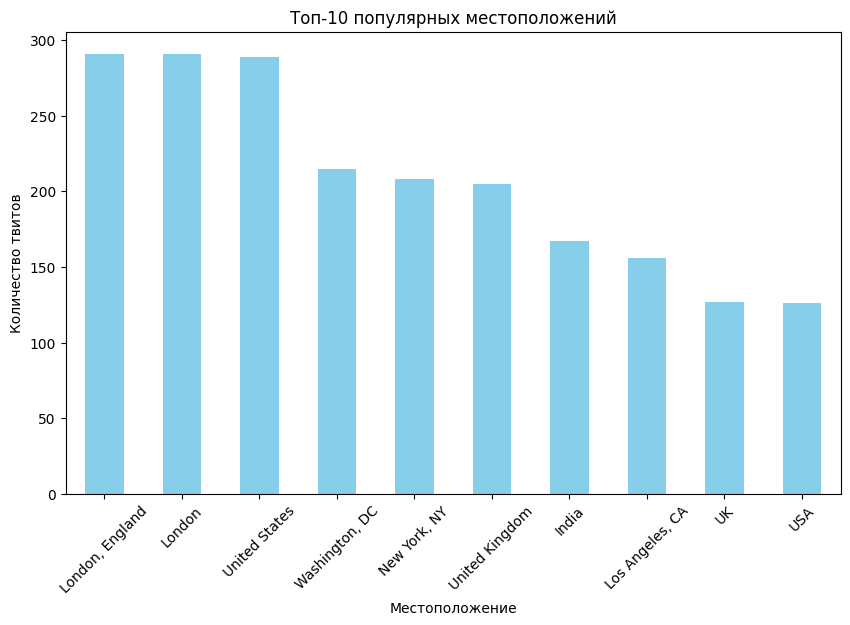

In [92]:
location_counts = train['Location'].value_counts()

if 'Unknown' in location_counts.index:
  location_counts = location_counts.drop('Unknown')

top_10_locations = location_counts.head(10)

plt.figure(figsize=(10, 6))
top_10_locations.plot(kind='bar', color='skyblue')
plt.title('Топ-10 популярных местоположений')
plt.xlabel('Местоположение')
plt.ylabel('Количество твитов')
plt.xticks(rotation=45)
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

Количество уникальных значений в WiderLocation: 4752

Пример уникальных значений:
['Canada' 'Sydney' 'London baby!!' 'England' 'TX' 'Unknown' 'Rwanda' 'USA'
 'France' 'Resistance City']


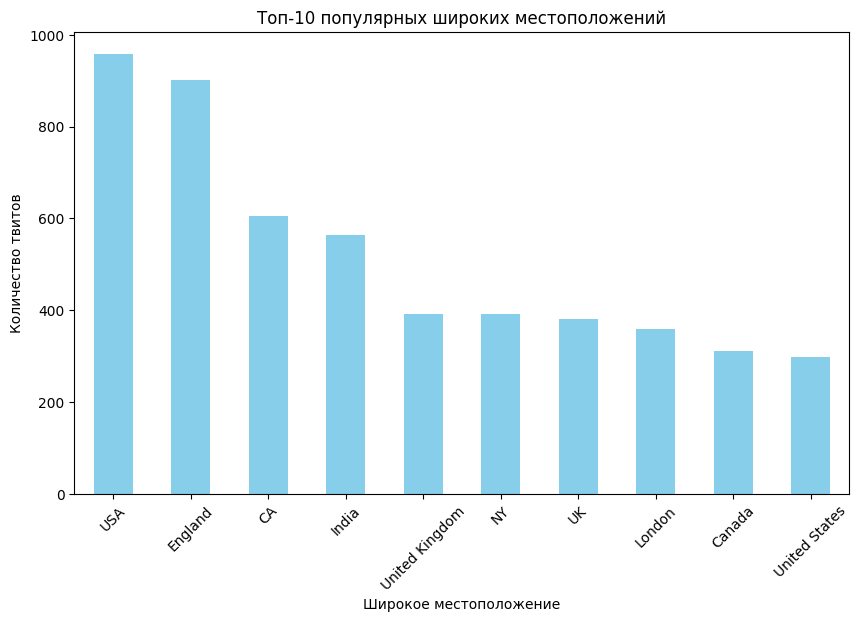

In [93]:
train['WiderLocation'] = train['Location'].apply(
    lambda x: x.split(',')[-1].strip() if isinstance(x, str) and ',' in x else x
)

test['WiderLocation'] = test['Location'].apply(
    lambda x: x.split(',')[-1].strip() if isinstance(x, str) and ',' in x else x
)

unique_wider_locations = train['WiderLocation'].nunique()
print(f"Количество уникальных значений в WiderLocation: {unique_wider_locations}")

print("\nПример уникальных значений:")
print(train['WiderLocation'].unique()[:10])

wider_location_counts = train['WiderLocation'].value_counts()

if 'Unknown' in wider_location_counts.index:
    wider_location_counts = wider_location_counts.drop('Unknown')

top_10_wider_locations = wider_location_counts.head(10)

plt.figure(figsize=(10, 6))
top_10_wider_locations.plot(kind='bar', color='skyblue')
plt.title('Топ-10 популярных широких местоположений')
plt.xlabel('Широкое местоположение')
plt.ylabel('Количество твитов')
plt.xticks(rotation=45)
plt.show()

Количество уникальных значений в WiderLocation: 4749


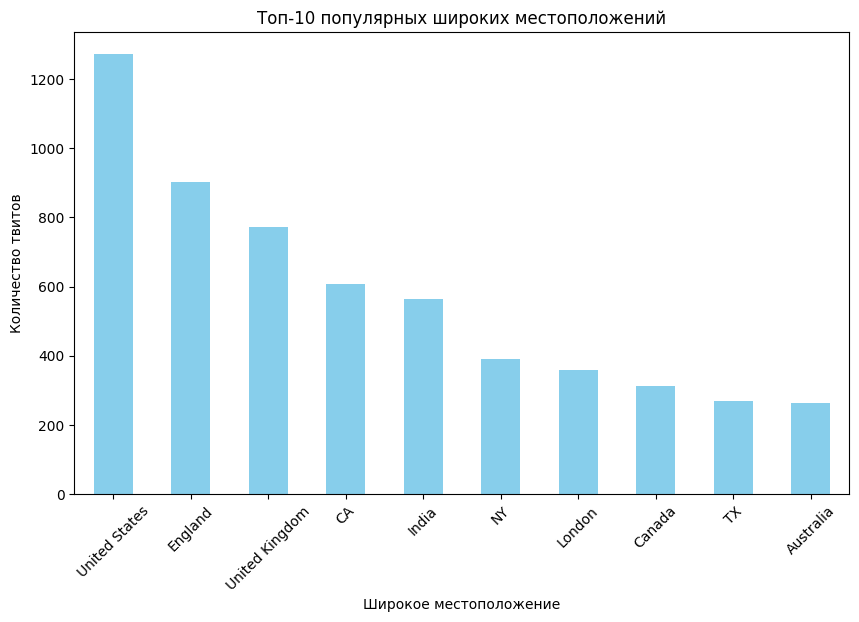

In [94]:
location_mapping = {
    'UK': 'United Kingdom',
    'USA': 'United States',
    'US': 'United States',
}

train['WiderLocation'] = train['WiderLocation'].apply(
    lambda x: location_mapping.get(x, x) if isinstance(x, str) else x
)

test['WiderLocation'] = test['WiderLocation'].apply(
    lambda x: location_mapping.get(x, x) if isinstance(x, str) else x
)

unique_wider_locations = train['WiderLocation'].nunique()
print(f"Количество уникальных значений в WiderLocation: {unique_wider_locations}")

wider_location_counts = train['WiderLocation'].value_counts()

if 'Unknown' in wider_location_counts.index:
    wider_location_counts = wider_location_counts.drop('Unknown')

top_10_wider_locations = wider_location_counts.head(10)

plt.figure(figsize=(10, 6))
top_10_wider_locations.plot(kind='bar', color='skyblue')
plt.title('Топ-10 популярных широких местоположений')
plt.xlabel('Широкое местоположение')
plt.ylabel('Количество твитов')
plt.xticks(rotation=45)
plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [95]:
location_counts = train['WiderLocation'].value_counts()
frequent_location = location_counts[location_counts > 1].index

train['WiderLocation_filtered'] = train['WiderLocation'].apply(
    lambda x: x if x in frequent_location else 'Unknown'
)

print(f'Количество WiderLocation после фильтрации: {train.WiderLocation_filtered.nunique()}')

location_counts = test['WiderLocation'].value_counts()
frequent_location = location_counts[location_counts > 1].index

test['WiderLocation_filtered'] = test['WiderLocation'].apply(
    lambda x: x if x in frequent_location else 'Unknown'
)

print(f'Количество WiderLocation после фильтрации: {test.WiderLocation_filtered.nunique()}')

Количество WiderLocation после фильтрации: 998
Количество WiderLocation после фильтрации: 520


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [96]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(categories=[frequent_location], handle_unknown='ignore')
wider_location_train = ohe.fit_transform(train['WiderLocation_filtered'].values.reshape(-1, 1))
wider_location_test = ohe.transform(test['WiderLocation_filtered'].values.reshape(-1, 1))

X_train_location = hstack([X_train_scaled, wider_location_train])
X_test_location = hstack([X_test_scaled, wider_location_test])

In [97]:
lr_combined = LogisticRegression(max_iter=1000, random_state=42)
lr_combined.fit(X_train_location, y_train)

y_train_pred_combined = lr_combined.predict(X_train_location)
y_test_pred_combined = lr_combined.predict(X_test_location)

accuracy_train_combined = accuracy_score(y_train, y_train_pred_combined)
accuracy_test_combined = accuracy_score(y_test, y_test_pred_combined)

print(f"Combined features - Accuracy на обучающих данных: {accuracy_train_combined:.4f}")
print(f"Combined features - Accuracy на тестовых данных: {accuracy_test_combined:.4f}")

Combined features - Accuracy на обучающих данных: 0.9469
Combined features - Accuracy на тестовых данных: 0.8468


Точность едва заметно снизилась. Вероятно местоположений слишком много, чтобы построить нормальную модель. Оно и понятно, на 23 тысячи тренировочных данных у нас 1 тысяча местоположений. Возможно стоит попробовать оставить местоположения, встречающиеся чаще скажем 10 раз.

## Задание 8 Хорошее качество (Бонус 1 балл)

Добейтесь accuracy=0.884 на тестовой выборке (можно сменить токенайзер, векторайзер, модель и т.д.)

Итак шкалирование снизило качество. Дата оказалась бесполезной, а локация едва заметно снизила качество. Без шкалирования мы получали Accuracy на тестовых данных: 0.8729

In [102]:
lr_count = LogisticRegression(max_iter=1000, C=0.5, penalty='l1', solver='saga', random_state=42)
lr_count.fit(X_train_count, y_train)

y_train_pred_count = lr_count.predict(X_train_count)
y_test_pred_count = lr_count.predict(X_test_count)

accuracy_train_count = accuracy_score(y_train, y_train_pred_count)
accuracy_test_count = accuracy_score(y_test, y_test_pred_count)

print(f"CountVectorizer_df - Accuracy на обучающих данных: {accuracy_train_count:.4f}")
print(f"CountVectorizer_df - Accuracy на тестовых данных: {accuracy_test_count:.4f}")

CountVectorizer_df - Accuracy на обучающих данных: 0.9106
CountVectorizer_df - Accuracy на тестовых данных: 0.8840


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
